In [1]:
import pandas as pd

crime = pd.read_csv("data/cleaned_crime_long.csv", parse_dates=["Date"])

borough_monthly = (
    crime.groupby(["Borough", "Date"])["CrimeCount"]
    .sum()
    .reset_index()
    .rename(columns={"CrimeCount": "TotalCrimes"})
)

# average and volatility (std) per borough - we already saw these in
# descriptive stats, now we'll use them as clustering features
borough_summary = (
    borough_monthly.groupby("Borough")["TotalCrimes"]
    .agg(AvgCrime="mean", CrimeStd="std")
    .reset_index()
)

print(borough_summary.shape)
print(borough_summary.head())

(32, 3)
                Borough     AvgCrime    CrimeStd
0  Barking and Dagenham  1528.937173  161.518212
1                Barnet  2204.020942  222.226981
2                Bexley  1197.560209  181.206121
3                 Brent  2384.047120  260.516194
4               Bromley  1837.010471  172.871324


In [2]:
recent_cutoff = borough_monthly["Date"].max() - pd.DateOffset(months=12)

recent_avg = (
    borough_monthly[borough_monthly["Date"] >= recent_cutoff]
    .groupby("Borough")["TotalCrimes"]
    .mean()
    .rename("RecentAvgCrime")
)

borough_summary = borough_summary.merge(recent_avg, on="Borough")

borough_summary["TrendRatio"] = (borough_summary["RecentAvgCrime"] / borough_summary["AvgCrime"]).round(3)

print(borough_summary.sort_values("TrendRatio", ascending=False))

                   Borough     AvgCrime     CrimeStd  RecentAvgCrime  \
31             Westminster  5323.162304  1446.825534     6753.153846   
23                  Newham  2797.303665   362.813236     3375.692308   
15              Hillingdon  2155.178010   269.280366     2582.230769   
5                   Camden  2836.759162   474.130089     3354.384615   
28           Tower Hamlets  2586.895288   355.796955     3037.307692   
26               Southwark  2854.303665   346.990311     3291.615385   
13                  Harrow  1206.068063   148.045941     1378.384615   
9                Greenwich  2030.387435   273.025691     2316.230769   
3                    Brent  2384.047120   260.516194     2706.692308   
16                Hounslow  2003.717277   225.982798     2222.000000   
17               Islington  2298.413613   265.781136     2544.615385   
8                  Enfield  2161.308901   304.676608     2387.769231   
21                Lewisham  2194.664921   247.409234     2423.38

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

features = ["AvgCrime", "CrimeStd", "TrendRatio"]
X = borough_summary[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("k | inertia | silhouette score")
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    print(f"{k} | {km.inertia_:.1f} | {sil:.3f}")

k | inertia | silhouette score
2 | 43.7 | 0.767
3 | 23.0 | 0.352
4 | 14.4 | 0.362
5 | 8.8 | 0.444
6 | 7.1 | 0.339
7 | 5.5 | 0.372


In [4]:
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
borough_summary["Cluster_k2"] = kmeans_2.fit_predict(X_scaled)

print(borough_summary.groupby("Cluster_k2")["Borough"].apply(list))
print()
print(borough_summary.groupby("Cluster_k2")[features].mean())

Cluster_k2
0    [Barking and Dagenham, Barnet, Bexley, Brent, ...
1                                        [Westminster]
Name: Borough, dtype: object

               AvgCrime     CrimeStd  TrendRatio
Cluster_k2                                      
0           1990.849856   233.541690    1.096871
1           5323.162304  1446.825534    1.269000


In [5]:
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
borough_summary["Cluster_k4"] = kmeans_4.fit_predict(X_scaled)

for cluster_id in sorted(borough_summary["Cluster_k4"].unique()):
    boroughs_in_cluster = borough_summary[borough_summary["Cluster_k4"] == cluster_id]["Borough"].tolist()
    print(f"Cluster {cluster_id}: {boroughs_in_cluster}")

print()
print(borough_summary.groupby("Cluster_k4")[features].mean())

Cluster 0: ['Barking and Dagenham', 'Bexley', 'Bromley', 'Hammersmith and Fulham', 'Harrow', 'Havering', 'Kensington and Chelsea', 'Kingston upon Thames', 'Merton', 'Redbridge', 'Richmond upon Thames', 'Sutton', 'Waltham Forest']
Cluster 1: ['Westminster']
Cluster 2: ['Camden', 'Hillingdon', 'Newham', 'Southwark', 'Tower Hamlets']
Cluster 3: ['Barnet', 'Brent', 'Croydon', 'Ealing', 'Enfield', 'Greenwich', 'Hackney', 'Haringey', 'Hounslow', 'Islington', 'Lambeth', 'Lewisham', 'Wandsworth']

               AvgCrime     CrimeStd  TrendRatio
Cluster_k4                                      
0           1423.200161   158.780901    1.064231
1           5323.162304  1446.825534    1.269000
2           2646.087958   361.802191    1.182800
3           2306.484897   258.971516    1.096462


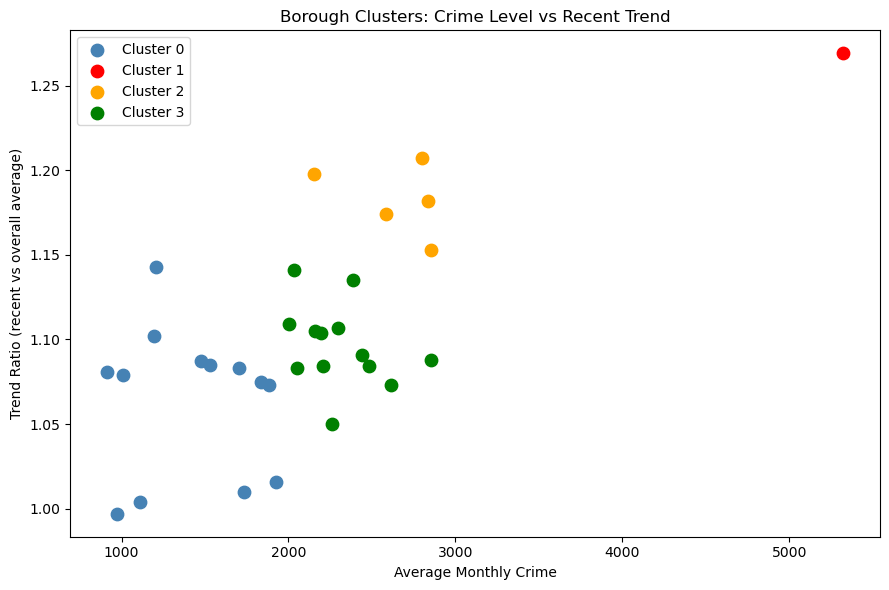

Saved!


In [6]:
borough_summary.to_csv("data/borough_clusters_final.csv", index=False)

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))
colors = ["steelblue", "red", "orange", "green"]
for cluster_id in sorted(borough_summary["Cluster_k4"].unique()):
    subset = borough_summary[borough_summary["Cluster_k4"] == cluster_id]
    plt.scatter(subset["AvgCrime"], subset["TrendRatio"], 
                label=f"Cluster {cluster_id}", color=colors[cluster_id], s=80)

plt.xlabel("Average Monthly Crime")
plt.ylabel("Trend Ratio (recent vs overall average)")
plt.title("Borough Clusters: Crime Level vs Recent Trend")
plt.legend()
plt.tight_layout()
plt.savefig("figures/11_borough_clusters.png", dpi=150)
plt.show()

print("Saved!")